In [77]:
import sys, os
import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.append("../src")
from MillerDataGen import (
    CompositionalDataGeneratorConfig,
    CompositionalDataGenerator,
)

# We will mirror the slot notebook's evaluation style
# but implement a non-slot model and a loss-level competition mechanism
%matplotlib inline


In [78]:
# Parameters and run flags
S1 = 24  # vocab size for feature 1
S2 = 24  # vocab size for feature 2
SEQ_LEN = 3
BATCH_SIZE = 128
NUM_SAMPLES = 2000
FEATURE_DIM = 32
INIT_SCALE = 1.0
LR = 7e-3
N_EPOCHS = 300
SEED = 1

TOPK_START = FEATURE_DIM  # start soft (use all dims)
TOPK_END = 2              # end
TOPK_ANNEAL_EPOCHS = int(0.6 * N_EPOCHS)

LAMBDA_SIM = 0.99
LAMBDA_REC = 0.01

device = "cuda" if torch.cuda.is_available() else "cpu"
np.random.seed(SEED)
torch.manual_seed(SEED)


In [79]:
# Build per-feature distance matrices (circular)

def circular_distance_matrix(S: int) -> torch.Tensor:
    t = torch.linspace(0, 1 - 1/S, S).unsqueeze(1)
    D = torch.zeros((S, S))
    for i in range(S):
        for j in range(S):
            D[i, j] = torch.min(torch.abs(t[i] - t[j]), 1 - torch.abs(t[i] - t[j]))
    return D

D1 = circular_distance_matrix(S1)
D2 = circular_distance_matrix(S2)

# Create compositional generator with the same inputs as slot notebook
comp_conf = CompositionalDataGeneratorConfig(
    num_slots=2,
    vocab_sizes=(S1, S2),
    sequence_len=SEQ_LEN,
    batch_size=BATCH_SIZE,
    slot_metric_matrices=(D1, D2),
    seed=SEED,
    num_samples=NUM_SAMPLES,
)
comp_gen = CompositionalDataGenerator(comp_conf)
comp_conf.device = device


In [80]:
from MillerTest import MillerTestConfig, create_model
from MillerTrainer import TrainerConfig
from MillerTest import MillerTestEvaluator


In [81]:
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

class NonSlotModel(nn.Module):
    def __init__(self, input_dim: int, feature_dim: int, activation: nn.Module):
        super().__init__()
        self.embed = nn.Linear(input_dim, feature_dim, bias=False)
        self.activation = activation
        self.is_compositional = False  # keep evaluator aware of non-slot status
    
    def forward(self, x: torch.Tensor):
        # x: [B, K, D]
        z = self.embed(x)  # [B, K, F]
        # tied reconstruction
        recon = self.activation(torch.matmul(z, self.embed.weight))  # [B, K, D]
        return z, recon

def compute_topk_outputs(z: torch.Tensor, k: int, activation: nn.Module) -> torch.Tensor:
    """
    Compute candidate-probe similarities using only top-k latent dims (competition in loss).
    z: [B, K, F]
    Returns: [B, K-1]
    """
    ctx = z[:, :-1, :]  # [B, K-1, F]
    probe = z[:, [-1], :]  # [B, 1, F]
    contrib = ctx * probe  # [B, K-1, F]
    # Select dims per sample based on max contribution magnitude over candidates
    # sel_scores = contrib.abs().amax(dim=1)  # [B, F]
    sel_scores = contrib.abs().sum(dim=1)  # [B, F]
    if k <= 0:
        k = 1
    k = min(k, sel_scores.shape[1])
    topk_vals, topk_idx = torch.topk(sel_scores, k=k, dim=1)
    mask = torch.zeros_like(sel_scores)
    mask.scatter_(1, topk_idx, 1.0)  # [B, F]
    contrib_masked = contrib * mask.unsqueeze(1)  # [B, K-1, F]
    sim = contrib_masked.sum(dim=2)  # [B, K-1]
    if isinstance(activation, nn.ReLU):
        sim = activation(sim) + 1e-10
    else:
        sim = activation(sim)
    return sim

def topk_for_epoch(epoch: int) -> int:
    if epoch >= TOPK_ANNEAL_EPOCHS:
        return TOPK_END
    # linearly anneal from START -> END over TOPK_ANNEAL_EPOCHS
    frac = epoch / max(1, TOPK_ANNEAL_EPOCHS)
    return max(TOPK_END, int(round(TOPK_START - (TOPK_START - TOPK_END) * frac)))

class NonSlotTrainer:
    def __init__(self, model: nn.Module, generator: CompositionalDataGenerator):
        self.model = model.to(device)
        self.gen = generator
        self.opt = Adam(self.model.parameters(), lr=LR, weight_decay=0.0)
        self.sched = ReduceLROnPlateau(self.opt, mode='max', patience=700, min_lr=0.0)
        self.history = {
            'similarity_scores': [],
            'identification_scores': [],
            'similarity_losses': [],
            'reconstruction_losses': [],
        }
        self.loss_nll = nn.NLLLoss()
        self.loss_rec = nn.MSELoss()
    
    def train_epoch(self, epoch: int):
        self.model.train()
        total_sim_loss = 0.0
        total_rec_loss = 0.0
        total_correct = 0.0
        total_samples = 0
        k = topk_for_epoch(epoch)
        num_batches = self.gen.config.num_samples // self.gen.config.batch_size
        for _ in range(num_batches):
            sim_indices, sim_labels = self.gen.generate_similarity_test_batch()
            x = self.gen.indices_to_inputs(sim_indices).to(device)
            sim_labels = sim_labels.to(device)
            self.opt.zero_grad()
            z, recon = self.model(x)
            sim_outputs = compute_topk_outputs(z, k=k, activation=self.model.activation)  # [B, K-1]
            sim_probs = (sim_outputs + 1e-12) / (sim_outputs.sum(dim=1, keepdim=True) + 1e-12)
            sim_loss = self.loss_nll(torch.log(sim_probs), sim_labels)
            loss = LAMBDA_SIM * sim_loss
            if LAMBDA_REC > 0.0:
                rec_loss = self.loss_rec(recon.reshape(-1, x.shape[-1]), x.reshape(-1, x.shape[-1]))
                loss = loss + LAMBDA_REC * rec_loss
                total_rec_loss += (LAMBDA_REC * rec_loss.item())
            loss.backward()
            self.opt.step()
            total_sim_loss += (LAMBDA_SIM * sim_loss.item())
            total_correct += sim_probs.gather(1, sim_labels.unsqueeze(1)).sum().item()
            total_samples += sim_labels.size(0)
        self.history['similarity_losses'].append(total_sim_loss / max(1, num_batches))
        self.history['reconstruction_losses'].append(total_rec_loss / max(1, num_batches))
        return {
            'similarity_loss': total_sim_loss / max(1, num_batches),
            'reconstruction_loss': total_rec_loss / max(1, num_batches)
        }
    
    @torch.no_grad()
    def validate(self, epoch: int, eval_k: int = TOPK_END):
        self.model.eval()
        k = eval_k
        k = topk_for_epoch(epoch)
        # Similarity (generalization)
        correct_sim = 0
        total_sim = 0
        # Identification
        correct_id = 0
        total_id = 0
        num_batches = self.gen.config.num_samples // self.gen.config.batch_size
        for _ in range(num_batches):
            # Similarity
            sim_indices, sim_labels = self.gen.generate_similarity_test_batch()
            x = self.gen.indices_to_inputs(sim_indices).to(device)
            z, _ = self.model(x)
            sim_outputs = compute_topk_outputs(z, k=k, activation=self.model.activation)
            sim_probs = (sim_outputs + 1e-12) / (sim_outputs.sum(dim=1, keepdim=True) + 1e-12)
            correct_sim += sim_probs.gather(1, sim_labels.unsqueeze(1).to(device)).sum().item()
            total_sim += sim_labels.size(0)
            # Identification
            id_indices, id_labels = self.gen.generate_identification_test_batch()
            x_id = self.gen.indices_to_inputs(id_indices).to(device)
            z_id, _ = self.model(x_id)
            id_outputs = compute_topk_outputs(z_id, k=k, activation=self.model.activation)
            id_probs = (id_outputs + 1e-12) / (id_outputs.sum(dim=1, keepdim=True) + 1e-12)
            correct_id += id_probs.gather(1, id_labels.unsqueeze(1).to(device)).sum().item()
            total_id += id_labels.size(0)
        g_score = correct_sim / max(1, total_sim)
        i_score = correct_id / max(1, total_id)
        self.history['similarity_scores'].append(g_score)
        self.history['identification_scores'].append(i_score)
        self.sched.step(g_score + i_score)
        return {'generalization_score': g_score, 'identification_score': i_score}


Epoch 0: G=0.5054, I=0.5573, k=32
Epoch 50: G=0.7598, I=0.9041, k=24
Epoch 100: G=0.7509, I=0.9063, k=15
Epoch 150: G=0.7457, I=0.8960, k=7
Epoch 200: G=0.7151, I=0.8802, k=2
Epoch 250: G=0.7188, I=0.8673, k=2


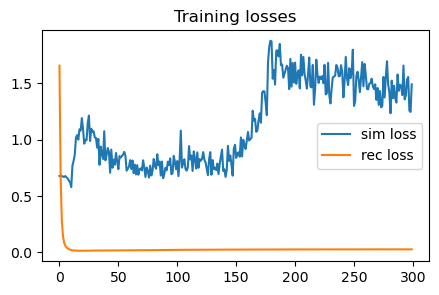

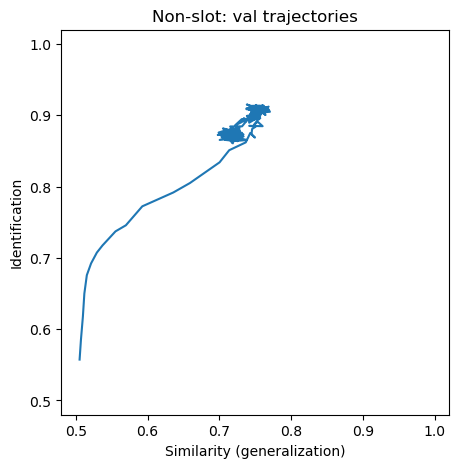

In [82]:
# Instantiate model and trainer, then train
model = NonSlotModel(input_dim=S1+S2, feature_dim=FEATURE_DIM, activation=torch.nn.ReLU())
# Initialize like slot model
torch.nn.init.uniform_(model.embed.weight, a=0.0, b=INIT_SCALE)

trainer = NonSlotTrainer(model, comp_gen)

similarity_losses = []
reconstruction_losses = []
g_scores = []
i_scores = []

for epoch in range(N_EPOCHS):
    train_metrics = trainer.train_epoch(epoch)
    val_metrics = trainer.validate(epoch)
    similarity_losses.append(train_metrics['similarity_loss'])
    reconstruction_losses.append(train_metrics['reconstruction_loss'])
    g_scores.append(val_metrics['generalization_score'])
    i_scores.append(val_metrics['identification_score'])
    if epoch % 50 == 0:
        print(f"Epoch {epoch}: G={val_metrics['generalization_score']:.4f}, I={val_metrics['identification_score']:.4f}, k={topk_for_epoch(epoch)}")

# Simple plots for quick comparison
plt.figure(figsize=(5,3))
plt.plot(similarity_losses, label='sim loss')
plt.plot(reconstruction_losses, label='rec loss')
plt.legend(); plt.title('Training losses')

plt.figure(figsize=(5,5))
plt.plot(g_scores, i_scores)
plt.xlim([0.48, 1.02]); plt.ylim([0.48, 1.02])
plt.xlabel('Similarity (generalization)'); plt.ylabel('Identification')
plt.title('Non-slot: val trajectories'); plt.show()


In [83]:
# Sweep non-slot model across number of features (slots in data) and track trajectories
from typing import Dict

def train_nonslot_with_features(num_features: int,
                                vocab_size: int = S1,
                                feature_dim: int = FEATURE_DIM,
                                n_epochs: int = 300,
                                seed: int = SEED) -> Dict:
    # Build per-feature distance matrices
    slot_distances = [circular_distance_matrix(vocab_size) for _ in range(num_features)]

    # Compositional data generator with `num_features` slots
    cfg = CompositionalDataGeneratorConfig(
        num_slots=num_features,
        vocab_sizes=tuple([vocab_size] * num_features),
        sequence_len=SEQ_LEN,
        batch_size=BATCH_SIZE,
        slot_metric_matrices=tuple(slot_distances),
        seed=seed,
        num_samples=NUM_SAMPLES,
        distance_aggregation="max",
    )
    cfg.device = device
    gen = CompositionalDataGenerator(cfg)

    # Non-slot model: one shared embedding over concatenated multi-hot inputs
    model = NonSlotModel(input_dim=num_features * vocab_size,
                         feature_dim=feature_dim,
                         activation=torch.nn.ReLU())
    torch.nn.init.uniform_(model.embed.weight, a=0.0, b=INIT_SCALE)

    trainer = NonSlotTrainer(model, gen)

    g_traj, i_traj = [], []
    sim_losses, rec_losses = [], []

    for epoch in range(n_epochs):
        train_metrics = trainer.train_epoch(epoch)
        val_metrics = trainer.validate(epoch, eval_k=TOPK_END)
        g_traj.append(val_metrics['generalization_score'])
        i_traj.append(val_metrics['identification_score'])
        sim_losses.append(train_metrics['similarity_loss'])
        rec_losses.append(train_metrics['reconstruction_loss'])
        if epoch % 50 == 0:
            print(f"  Epoch {epoch}: G={g_traj[-1]:.3f}, I={i_traj[-1]:.3f}")

    return {
        'history': {
            'g': g_traj,
            'i': i_traj,
            'similarity_losses': sim_losses,
            'reconstruction_losses': rec_losses,
        },
        'final_g_score': g_traj[-1],
        'final_i_score': i_traj[-1],
        'num_features': num_features,
    }

# Run experiments for specified feature counts
feature_counts = [1, 2, 3, 5, 7, 10, 15]
print("Training non-slot model across feature counts...")
non_slot_experiments: Dict[int, Dict] = {}
for nf in feature_counts:
    print(f"\nTraining with {nf} features:")
    non_slot_experiments[nf] = train_nonslot_with_features(
        num_features=nf,
        vocab_size=S1,
        feature_dim=FEATURE_DIM,
        n_epochs=300,
        seed=SEED,
    )
    print(f"  Final: G={non_slot_experiments[nf]['final_g_score']:.3f}, I={non_slot_experiments[nf]['final_i_score']:.3f}")


Training non-slot model across feature counts...

Training with 1 features:
  Epoch 0: G=0.505, I=0.597
  Epoch 50: G=0.734, I=0.911
  Epoch 100: G=0.733, I=0.913
  Epoch 150: G=0.717, I=0.912
  Epoch 200: G=0.730, I=0.906
  Epoch 250: G=0.722, I=0.904
  Final: G=0.703, I=0.908

Training with 2 features:
  Epoch 0: G=0.502, I=0.557
  Epoch 50: G=0.718, I=0.897
  Epoch 100: G=0.717, I=0.894
  Epoch 150: G=0.702, I=0.878
  Epoch 200: G=0.689, I=0.856
  Epoch 250: G=0.686, I=0.848
  Final: G=0.700, I=0.849

Training with 3 features:
  Epoch 0: G=0.500, I=0.541
  Epoch 50: G=0.582, I=0.751
  Epoch 100: G=0.591, I=0.755
  Epoch 150: G=0.575, I=0.718
  Epoch 200: G=0.530, I=0.604
  Epoch 250: G=0.535, I=0.609
  Final: G=0.551, I=0.625

Training with 5 features:
  Epoch 0: G=0.499, I=0.524
  Epoch 50: G=0.545, I=0.730
  Epoch 100: G=0.564, I=0.749
  Epoch 150: G=0.541, I=0.686
  Epoch 200: G=0.509, I=0.569
  Epoch 250: G=0.511, I=0.568
  Final: G=0.513, I=0.573

Training with 7 features:
  Ep

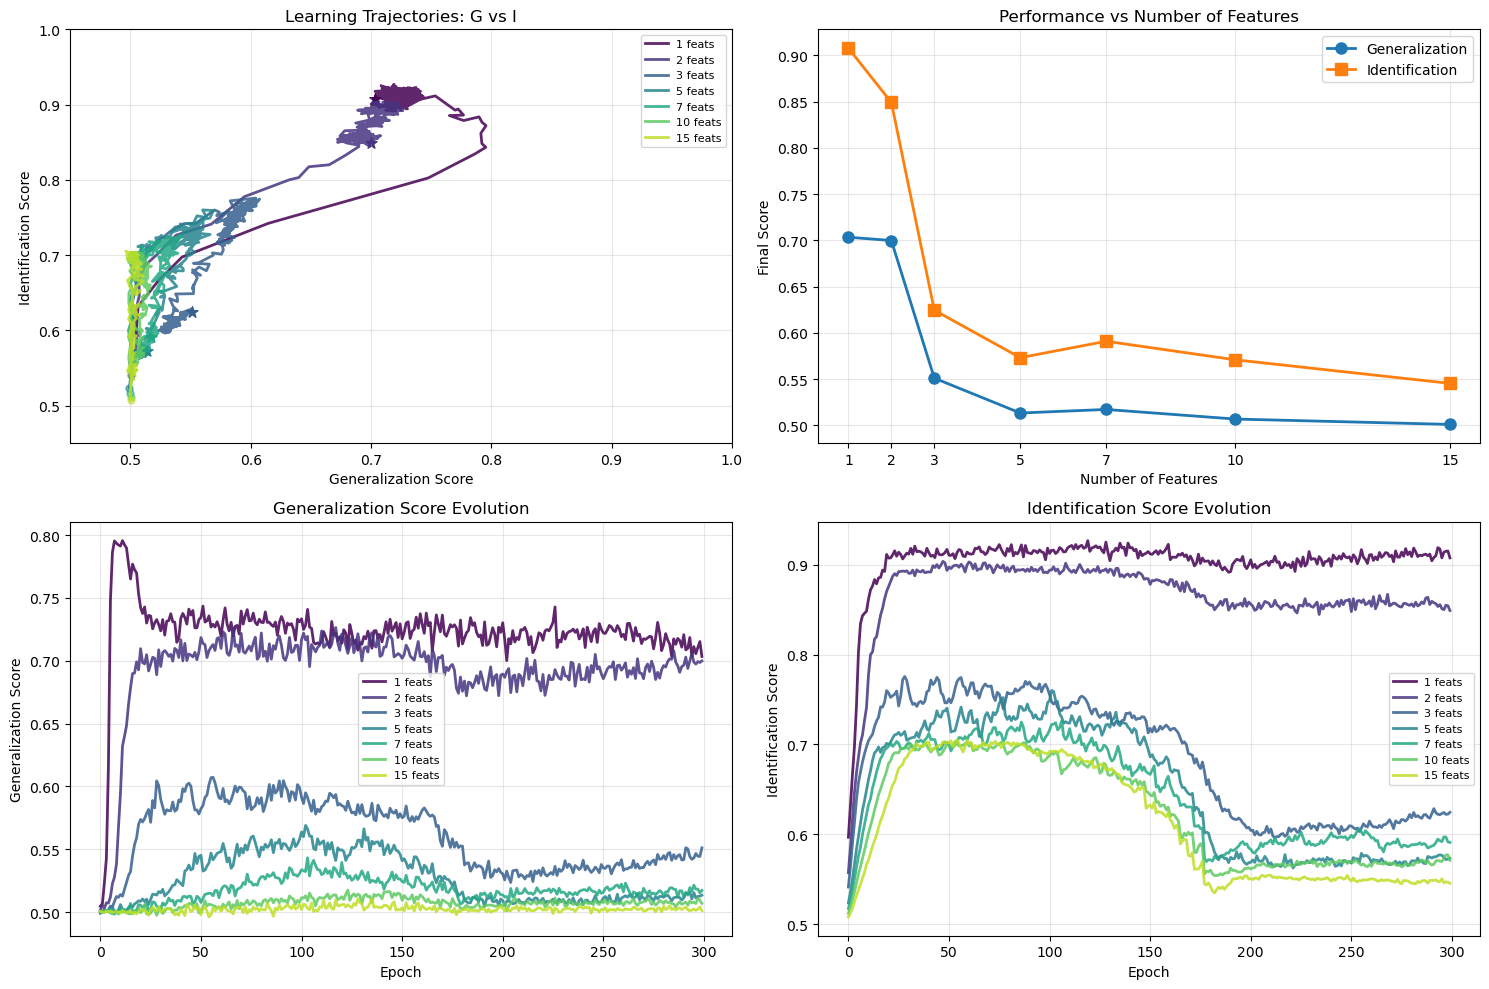


Summary (Non-slot across features):
1 features: G=0.703, I=0.908
2 features: G=0.700, I=0.849
3 features: G=0.551, I=0.625
5 features: G=0.513, I=0.573
7 features: G=0.517, I=0.591
10 features: G=0.507, I=0.571
15 features: G=0.501, I=0.545


In [84]:
# Plot: (1) Learning trajectories G vs I; (2) Performance vs #features;
#       (3) Generalization over epochs; (4) Identification over epochs
from matplotlib import cm

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
colors = cm.viridis(np.linspace(0, 0.9, len(feature_counts)))

# 1) G vs I trajectories
ax = axes[0]
for idx, nf in enumerate(feature_counts):
    exp = non_slot_experiments[nf]['history']
    ax.plot(exp['g'], exp['i'], label=f'{nf} feats', color=colors[idx], linewidth=2, alpha=0.85)
    ax.scatter(exp['g'][0], exp['i'][0], color=colors[idx], s=25, alpha=0.6)
    ax.scatter(exp['g'][-1], exp['i'][-1], color=colors[idx], s=70, marker='*')
ax.set_xlabel('Generalization Score')
ax.set_ylabel('Identification Score')
ax.set_title('Learning Trajectories: G vs I')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim([0.45, 1.0])
ax.set_ylim([0.45, 1.0])

# 2) Final performance vs number of features
ax = axes[1]
final_g = [non_slot_experiments[n]['history']['g'][-1] for n in feature_counts]
final_i = [non_slot_experiments[n]['history']['i'][-1] for n in feature_counts]
ax.plot(feature_counts, final_g, 'o-', label='Generalization', markersize=8, linewidth=2)
ax.plot(feature_counts, final_i, 's-', label='Identification', markersize=8, linewidth=2)
ax.set_xlabel('Number of Features')
ax.set_ylabel('Final Score')
ax.set_title('Performance vs Number of Features')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(feature_counts)

# 3) Generalization score evolution
ax = axes[2]
for idx, nf in enumerate(feature_counts):
    exp = non_slot_experiments[nf]['history']
    ax.plot(exp['g'], label=f'{nf} feats', color=colors[idx], linewidth=2, alpha=0.85)
ax.set_xlabel('Epoch')
ax.set_ylabel('Generalization Score')
ax.set_title('Generalization Score Evolution')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 4) Identification score evolution
ax = axes[3]
for idx, nf in enumerate(feature_counts):
    exp = non_slot_experiments[nf]['history']
    ax.plot(exp['i'], label=f'{nf} feats', color=colors[idx], linewidth=2, alpha=0.85)
ax.set_xlabel('Epoch')
ax.set_ylabel('Identification Score')
ax.set_title('Identification Score Evolution')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Summary (Non-slot across features):")
print("="*60)
for nf in feature_counts:
    exp = non_slot_experiments[nf]['history']
    print(f"{nf} features: G={exp['g'][-1]:.3f}, I={exp['i'][-1]:.3f}")
